In [1]:
!pip install -q transformers torchmetrics

In [3]:
import os
import json
import time
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import DetrImageProcessor, DetrForObjectDetection
from torchmetrics.detection.mean_ap import MeanAveragePrecision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


In [4]:
DATASET_ROOT = "/kaggle/input/datasets/georgelukaanya/hospitalcocoversion"

TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "train")
VAL_IMG_DIR   = os.path.join(DATASET_ROOT, "valid")
TEST_IMG_DIR  = os.path.join(DATASET_ROOT, "test")

TRAIN_JSON = os.path.join(TRAIN_IMG_DIR, "_annotations.coco.json")
VAL_JSON   = os.path.join(VAL_IMG_DIR, "_annotations.coco.json")
TEST_JSON  = os.path.join(TEST_IMG_DIR, "_annotations.coco.json")

for p in [TRAIN_IMG_DIR, VAL_IMG_DIR, TEST_IMG_DIR, TRAIN_JSON, VAL_JSON, TEST_JSON]:
    print(p, "->", os.path.exists(p))

/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/train -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/test -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/train/_annotations.coco.json -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/_annotations.coco.json -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/test/_annotations.coco.json -> True


In [5]:
with open(TRAIN_JSON, "r") as f:
    train_coco = json.load(f)

with open(VAL_JSON, "r") as f:
    val_coco = json.load(f)

with open(TEST_JSON, "r") as f:
    test_coco = json.load(f)

print("Train images:", len(train_coco["images"]))
print("Val images:", len(val_coco["images"]))
print("Test images:", len(test_coco["images"]))
print("Train annotations:", len(train_coco["annotations"]))

Train images: 5195
Val images: 272
Test images: 146
Train annotations: 8745


,class_id,class_name,train_count
0,1,Monitor,2185
1,3,bed,1930
2,6,sofa,1285
3,8,tools_table,895
4,7,stool,850
5,2,Saline Stand,770
6,5,chair,720
7,4,bin,110
8,0,tool,0


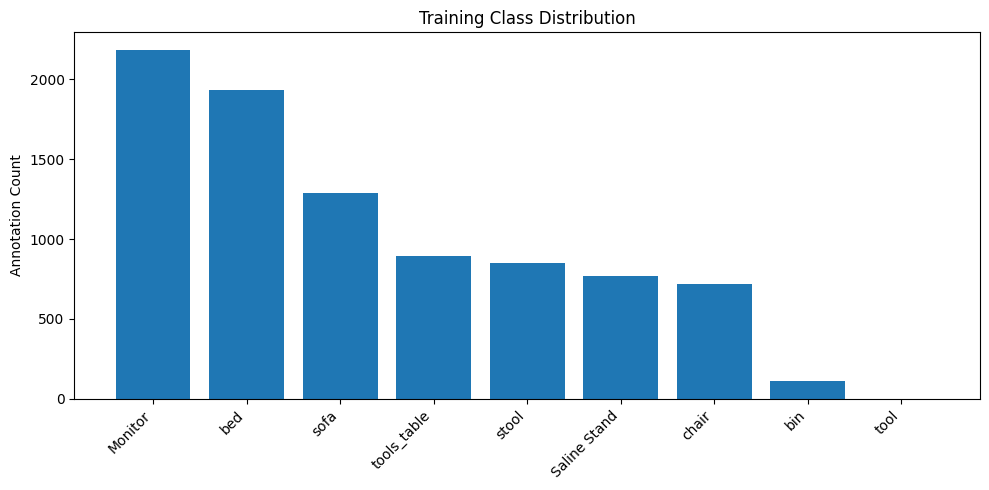

In [6]:
cat_id_to_name = {cat["id"]: cat["name"] for cat in train_coco["categories"]}
train_class_counts = Counter(ann["category_id"] for ann in train_coco["annotations"])

class_df = pd.DataFrame([
    {
        "class_id": cid,
        "class_name": cat_id_to_name[cid],
        "train_count": train_class_counts.get(cid, 0)
    }
    for cid in sorted(cat_id_to_name.keys())
]).sort_values("train_count", ascending=False).reset_index(drop=True)

display(class_df)

plt.figure(figsize=(10, 5))
plt.bar(class_df["class_name"], class_df["train_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Annotation Count")
plt.title("Training Class Distribution")
plt.tight_layout()
plt.show()

In [7]:
categories_sorted = sorted(train_coco["categories"], key=lambda x: x["id"])

orig_id_to_detr = {cat["id"]: i for i, cat in enumerate(categories_sorted)}
detr_to_orig_id = {i: cat["id"] for i, cat in enumerate(categories_sorted)}

id2label = {i: cat["name"] for i, cat in enumerate(categories_sorted)}
label2id = {v: k for k, v in id2label.items()}

num_classes = len(id2label)
print("Classes:", id2label)

Classes: {0: 'tool', 1: 'Monitor', 2: 'Saline Stand', 3: 'bed', 4: 'bin', 5: 'chair', 6: 'sofa', 7: 'stool', 8: 'tools_table'}


In [8]:
processor = DetrImageProcessor.from_pretrained(
    "facebook/detr-resnet-50",
    size={"shortest_edge": 640, "longest_edge": 960}
)

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

In [9]:
class CocoRawDetrDataset(Dataset):
    def __init__(self, coco_dict, img_dir, id_map, train=False):
        self.coco = coco_dict
        self.img_dir = img_dir
        self.id_map = id_map
        self.train = train

        self.images = coco_dict["images"]
        self.annotations = coco_dict["annotations"]

        self.image_id_to_anns = defaultdict(list)
        for ann in self.annotations:
            self.image_id_to_anns[ann["image_id"]].append(ann)

    def __len__(self):
        return len(self.images)

    def _sanitize_annotations(self, anns, width, height):
        cleaned = []

        for ann in anns:
            if "bbox" not in ann:
                continue

            x, y, w, h = ann["bbox"]

            vals = [x, y, w, h]
            if not all(np.isfinite(v) for v in vals):
                continue

            if w <= 1 or h <= 1:
                continue

            x = max(0, float(x))
            y = max(0, float(y))
            w = float(w)
            h = float(h)

            if x >= width or y >= height:
                continue

            w = min(w, width - x)
            h = min(h, height - y)

            if w <= 1 or h <= 1:
                continue

            new_ann = {
                "id": ann.get("id", 0),
                "image_id": ann["image_id"],
                "category_id": self.id_map[ann["category_id"]],
                "bbox": [x, y, w, h],
                "area": float(w * h),
                "iscrowd": int(ann.get("iscrowd", 0))
            }
            cleaned.append(new_ann)

        return cleaned

    def _horizontal_flip(self, image, anns):
        image = image.transpose(Image.FLIP_LEFT_RIGHT)
        width, _ = image.size

        flipped = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            new_x = width - (x + w)
            ann_new = ann.copy()
            ann_new["bbox"] = [new_x, y, w, h]
            flipped.append(ann_new)

        return image, flipped

    def __getitem__(self, idx):
        img_info = self.images[idx]
        image_id = img_info["id"]
        img_path = os.path.join(self.img_dir, img_info["file_name"])

        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        anns = self.image_id_to_anns[image_id]
        anns = self._sanitize_annotations(anns, width, height)

        if self.train and random.random() < 0.5:
            image, anns = self._horizontal_flip(image, anns)
            anns = self._sanitize_annotations(anns, image.size[0], image.size[1])

        return {
            "image": image,
            "image_id": image_id,
            "annotations": anns,
            "file_name": img_info["file_name"],
            "orig_size": (height, width)
        }

In [10]:
train_dataset = CocoRawDetrDataset(train_coco, TRAIN_IMG_DIR, orig_id_to_detr, train=True)
val_dataset   = CocoRawDetrDataset(val_coco, VAL_IMG_DIR, orig_id_to_detr, train=False)
test_dataset  = CocoRawDetrDataset(test_coco, TEST_IMG_DIR, orig_id_to_detr, train=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

5195 272 146


In [11]:
bad_samples = []

for i in range(min(len(train_dataset), 200)):
    try:
        sample = train_dataset[i]
        anns = sample["annotations"]

        for ann in anns:
            x, y, w, h = ann["bbox"]
            if not np.isfinite([x, y, w, h]).all():
                bad_samples.append((i, "non_finite_bbox"))
            if w <= 0 or h <= 0:
                bad_samples.append((i, "non_positive_bbox"))

    except Exception as e:
        bad_samples.append((i, str(e)))

print("Bad samples found:", len(bad_samples))
print(bad_samples[:20])

Bad samples found: 0
[]


In [12]:
def collate_fn(batch):
    images = [item["image"] for item in batch]
    annotations = [
        {
            "image_id": item["image_id"],
            "annotations": item["annotations"]
        }
        for item in batch
    ]

    encoding = processor(
        images=images,
        annotations=annotations,
        return_tensors="pt"
    )

    out = {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask": encoding["pixel_mask"],
        "labels": encoding["labels"],
        "orig_sizes": [item["orig_size"] for item in batch],
        "file_names": [item["file_name"] for item in batch]
    }
    return out

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 5195
Val batches: 272


In [14]:
batch = next(iter(train_loader))

print("pixel_values shape:", batch["pixel_values"].shape)
print("pixel_mask shape:", batch["pixel_mask"].shape)

for i, lab in enumerate(batch["labels"]):
    print(f"\nSample {i}")
    print("keys:", lab.keys())
    print("boxes shape:", lab["boxes"].shape)
    print("class_labels shape:", lab["class_labels"].shape)
    print("boxes finite:", torch.isfinite(lab["boxes"]).all().item())
    if lab["boxes"].numel() > 0:
        print("boxes min:", lab["boxes"].min().item())
        print("boxes max:", lab["boxes"].max().item())

pixel_values shape: torch.Size([1, 3, 640, 640])
pixel_mask shape: torch.Size([1, 640, 640])

Sample 0
keys: KeysView({'size': tensor([640, 640]), 'image_id': tensor([1913]), 'class_labels': tensor([3, 6, 1]), 'boxes': tensor([[0.3998, 0.6553, 0.4128, 0.5312],
        [0.8688, 0.7023, 0.2043, 0.3733],
        [0.2269, 0.3490, 0.1394, 0.1277]]), 'area': tensor([89834.3750, 31244.4570,  7290.8447]), 'iscrowd': tensor([0, 0, 0]), 'orig_size': tensor([1024, 1024])})
boxes shape: torch.Size([3, 4])
class_labels shape: torch.Size([3])
boxes finite: True
boxes min: 0.127685546875
boxes max: 0.8687744140625


In [15]:
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.to(device)
print("Model ready.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                       

Model ready.


In [16]:
for param in model.model.backbone.parameters():
    param.requires_grad = False

In [17]:
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-5,
    weight_decay=1e-4
)

In [18]:
batch = next(iter(train_loader))

pixel_values = batch["pixel_values"].to(device)
pixel_mask = batch["pixel_mask"].to(device)
labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

with torch.no_grad():
    outputs = model(
        pixel_values=pixel_values,
        pixel_mask=pixel_mask,
        labels=labels
    )

print("Initial loss:", outputs.loss.item())
print("Loss finite:", torch.isfinite(outputs.loss).item())

Initial loss: 3.9662587642669678
Loss finite: True


In [19]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    valid_steps = 0

    for step, batch in enumerate(loader):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        if not torch.isfinite(pixel_values).all():
            print(f"Skipping step {step}: non-finite pixel_values")
            continue

        bad_label = False
        for t in labels:
            if not torch.isfinite(t["boxes"]).all():
                print(f"Skipping step {step}: non-finite boxes")
                bad_label = True
                break
            if not torch.isfinite(t["class_labels"]).all():
                print(f"Skipping step {step}: non-finite class labels")
                bad_label = True
                break

        if bad_label:
            continue

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            labels=labels
        )

        loss = outputs.loss

        if not torch.isfinite(loss):
            print(f"Skipping step {step}: non-finite loss")
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()

        running_loss += loss.item()
        valid_steps += 1

        if step % 200 == 0:
            print(f"Step {step}: loss={loss.item():.4f}")

    return running_loss / max(valid_steps, 1)

In [20]:
@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()
    running_loss = 0.0
    valid_steps = 0

    for step, batch in enumerate(loader):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        if not torch.isfinite(pixel_values).all():
            continue

        bad_label = False
        for t in labels:
            if not torch.isfinite(t["boxes"]).all():
                bad_label = True
                break
            if not torch.isfinite(t["class_labels"]).all():
                bad_label = True
                break

        if bad_label:
            continue

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            labels=labels
        )

        loss = outputs.loss
        if torch.isfinite(loss):
            running_loss += loss.item()
            valid_steps += 1

    return running_loss / max(valid_steps, 1)

In [21]:
num_epochs = 3
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = "/kaggle/working/best_detr.pth"

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "id2label": id2label,
                "label2id": label2id
            },
            best_model_path
        )
        print("Saved best model.")

Step 0: loss=3.6723
Step 200: loss=2.1566
Step 400: loss=1.1641
Step 600: loss=3.4583
Step 800: loss=1.6973
Step 1000: loss=0.8106
Step 1200: loss=0.9426
Step 1400: loss=0.6029
Step 1600: loss=0.6920
Step 1800: loss=1.6556
Step 2000: loss=0.6729
Step 2200: loss=1.3400
Step 2400: loss=0.4949
Step 2600: loss=1.3386
Step 2800: loss=0.3605
Step 3000: loss=2.4233
Step 3200: loss=0.7032
Step 3400: loss=1.2558
Step 3600: loss=0.7136
Step 3800: loss=1.9847
Step 4000: loss=0.5843
Step 4200: loss=0.3379
Step 4400: loss=0.4849
Step 4600: loss=0.7775
Step 4800: loss=0.9413
Step 5000: loss=0.7285

Epoch 1/3
Train Loss: 1.0363
Val Loss:   0.7966
Saved best model.
Step 0: loss=0.6890
Step 200: loss=0.3952
Step 400: loss=1.1467
Step 600: loss=0.5289
Step 800: loss=0.3848
Step 1000: loss=0.4785
Step 1200: loss=0.4989
Step 1400: loss=0.8124
Step 1600: loss=0.4828
Step 1800: loss=0.2923
Step 2000: loss=0.3975
Step 2200: loss=0.4028
Step 2400: loss=0.5757
Step 2600: loss=0.4486
Step 2800: loss=1.5275
Step

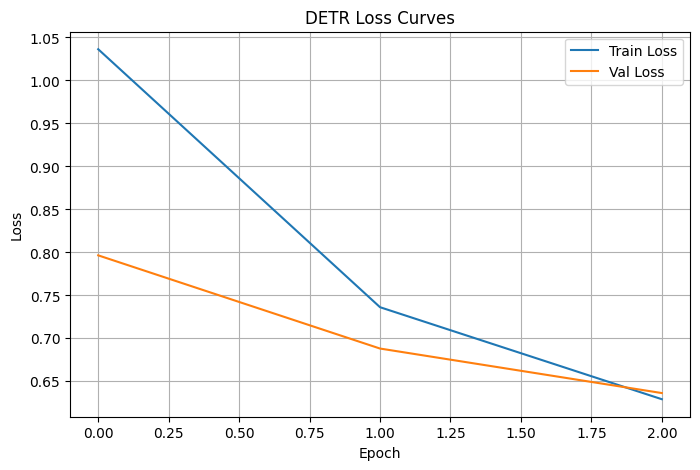

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DETR Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Loaded best model.")

Loaded best model.


In [24]:
@torch.no_grad()
def evaluate_map(model, loader, processor, device):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)

    for batch in loader:
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = batch["labels"]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        target_sizes = torch.tensor(batch["orig_sizes"], device=device)
        preds_processed = processor.post_process_object_detection(
            outputs,
            threshold=0.0,
            target_sizes=target_sizes
        )

        preds = []
        gts = []

        for pred, tgt, orig_size in zip(preds_processed, labels, batch["orig_sizes"]):
            preds.append({
                "boxes": pred["boxes"].cpu(),
                "scores": pred["scores"].cpu(),
                "labels": pred["labels"].cpu()
            })

            # tgt["boxes"] is normalized cxcywh
            gt_boxes = tgt["boxes"].cpu()
            gt_labels = tgt["class_labels"].cpu()

            h, w = orig_size
            scale = torch.tensor([w, h, w, h], dtype=gt_boxes.dtype)
            gt_boxes_abs = gt_boxes * scale

            cx, cy, bw, bh = gt_boxes_abs.unbind(-1)
            x1 = cx - bw / 2
            y1 = cy - bh / 2
            x2 = cx + bw / 2
            y2 = cy + bh / 2
            gt_boxes_xyxy = torch.stack([x1, y1, x2, y2], dim=-1)

            gts.append({
                "boxes": gt_boxes_xyxy,
                "labels": gt_labels
            })

        metric.update(preds, gts)

    return metric.compute()

In [25]:
map_results = evaluate_map(model, val_loader, processor, device)

for k, v in map_results.items():
    print(k, v)

map tensor(0.4551)
map_50 tensor(0.5639)
map_75 tensor(0.4868)
map_small tensor(0.)
map_medium tensor(0.1430)
map_large tensor(0.4616)
mar_1 tensor(0.4944)
mar_10 tensor(0.6483)
mar_100 tensor(0.6591)
mar_small tensor(0.)
mar_medium tensor(0.1786)
mar_large tensor(0.6686)
map_per_class tensor([0.4080, 0.4784, 0.5828, 0.0000, 0.4113, 0.8084, 0.7577, 0.1943])
mar_100_per_class tensor([0.6608, 0.6805, 0.8550, 0.0000, 0.6250, 0.8594, 0.8455, 0.7468])
classes tensor([1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.int32)


In [26]:
@torch.no_grad()
def measure_inference_speed(model, loader, device, num_batches=20):
    model.eval()
    times = []

    for i, batch in enumerate(loader):
        if i >= num_batches:
            break

        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()

        _ = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end = time.time()

        times.append(end - start)

    avg_time = np.mean(times)
    fps = 1.0 / avg_time if avg_time > 0 else 0.0
    return {"avg_time_sec": avg_time, "fps": fps}

In [27]:
speed = measure_inference_speed(model, val_loader, device)
print(speed)

{'avg_time_sec': np.float64(0.026938509941101075), 'fps': np.float64(37.12157807489802)}


In [28]:
@torch.no_grad()
def show_predictions(model, dataset, processor, index=0, score_thresh=0.5):
    model.eval()

    sample = dataset[index]
    image = sample["image"]

    inputs = processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)

    target_sizes = torch.tensor([[image.size[1], image.size[0]]], device=device)
    results = processor.post_process_object_detection(
        outputs,
        threshold=score_thresh,
        target_sizes=target_sizes
    )[0]

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image)
    ax.set_title("DETR Predictions")

    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(
            x1, y1,
            f"{id2label[int(label)]} {float(score):.2f}",
            fontsize=10,
            bbox=dict(facecolor="yellow", alpha=0.5)
        )

    plt.show()

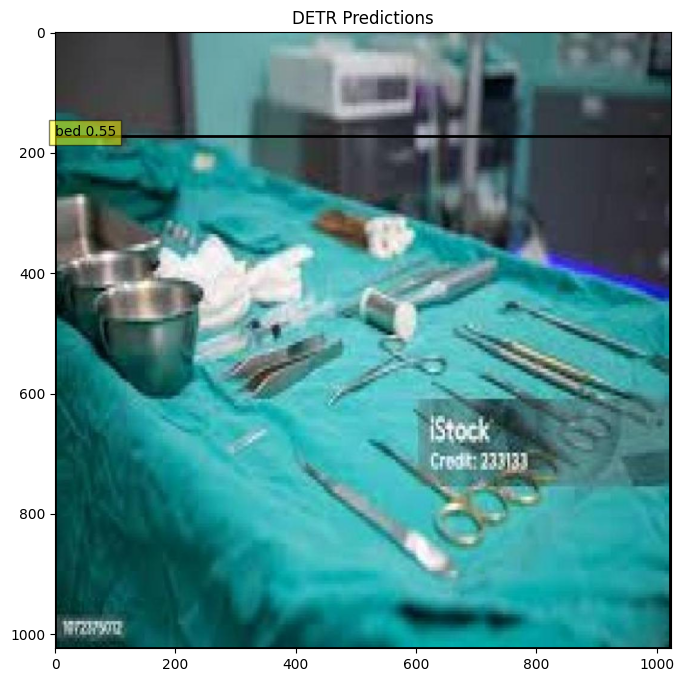

In [29]:
show_predictions(model, val_dataset, processor, index=0, score_thresh=0.5)

In [30]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "id2label": id2label,
        "label2id": label2id
    },
    "/kaggle/working/detr_final.pth"
)

print("Saved to /kaggle/working/")

Saved to /kaggle/working/
